# Libraries and preamble

In [65]:
install.packages("faraway")
install.packages("reshape2")
install.packages("Matching")
library(faraway)
library(tidyverse)
library(tidyr)
library(dplyr)
library(ggplot2)
library(reshape2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [66]:
library(data.table)

# F4.2

## F4.2.a

In [74]:
teengamb_base_lm <- lm (
    gamble ~ .,
    data = teengamb
)

In [75]:
summary(teengamb_base_lm)


Call:
lm(formula = gamble ~ ., data = teengamb)

Residuals:
    Min      1Q  Median      3Q     Max 
-51.082 -11.320  -1.451   9.452  94.252 

Coefficients: (1 not defined because of singularities)
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  22.55565   17.19680   1.312   0.1968    
sex         -22.11833    8.21111  -2.694   0.0101 *  
status        0.05223    0.28111   0.186   0.8535    
income        4.96198    1.02539   4.839 1.79e-05 ***
verbal       -2.95949    2.17215  -1.362   0.1803    
sex_fFemale        NA         NA      NA       NA    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 22.69 on 42 degrees of freedom
Multiple R-squared:  0.5267,	Adjusted R-squared:  0.4816 
F-statistic: 11.69 on 4 and 42 DF,  p-value: 1.815e-06


In [76]:
head(teengamb)

,sex,status,income,verbal,gamble,sex_f
,<int>,<int>,<dbl>,<int>,<dbl>,<fct>
1,1,51,2.00,8,0.0,Female
2,1,28,2.50,8,0.0,Female
3,1,37,2.00,6,0.0,Female
4,1,28,7.00,4,7.3,Female
5,1,65,2.00,8,19.6,Female
6,1,61,3.47,6,0.1,Female


In [77]:
teengamb_male_average <- teengamb %>% 
    filter(sex == 0) %>%
    summarise(across(c(verbal, income, status), \(x) mean(x, na.rm = TRUE))) %>%
    as.data.frame()

In [78]:
# Make predictions on new data X_test
teengamb_male_average_prediction <- 
    predict(
        teengamb_base_lm, 
        newdata = teengamb_male_average,
        interval = "prediction", 
        level = 0.95
)


ERROR: Error in eval(predvars, data, env): object 'sex' not found


In [79]:
teengamb_male_average_prediction

,fit,lwr,upr
1,29.775,-16.82649,76.37649


Our prediction for the average male is 29.775 and the CI interval at 0.95 is (-16826, 76.37649) which is non sensible.

## F4.2.b

In [80]:
teengamb_male_max <- teengamb %>% 
    summarise(across(everything(), max))

ERROR: [1m[33mError[39m in `summarise()`:[22m
[1m[22m[36mℹ[39m In argument: `across(everything(), max)`.
[1mCaused by error in `across()`:[22m
[1m[22m[33m![39m Can't compute column `sex_f`.
[1mCaused by error in `Summary.factor()`:[22m
[33m![39m ‘max’ not meaningful for factors


In [ ]:
teengamb_male_max_prediction <-
    predict(
        teengamb_base_lm, 
        newdata = teengamb_male_max,
        interval = "prediction", 
        level = 0.95
)

ERROR: Error in eval(predvars, data, env): object 'sex_f' not found


In [ ]:
teengamb_male_max_prediction

For males with the highest values in predictors, the dependent value is 49.1896120726776 and the CI at 0.95 is (-9.25, 107.63) which too is non-sensical.

## F4.2.c

In [ ]:
teengamb_sqrt_lm <- 
    lm(sqrt(gamble) ~ ., data = teengamb)

In [ ]:
summary(teengamb_sqrt_lm)

Note from the student: The question says 'The Individual' here is ambiguous. So, I will do it for both the average and the maximum case.

### The sqrt prediction for the teengamb male average is:

In [ ]:
teengamb_sqrt_male_max_prediction <-
    predict(
        teengamb_sqrt_lm, 
        newdata = teengamb_male_max,
        interval = "prediction", 
        level = 0.95
)

In [ ]:
teengamb_male_max_prediction

The predicted value of teengamb for a male with maximum predictors is 49.18. The CI intervals with 95% confidence are (-9.25,107.62) The negative is steill not the most sensible.

### The sqrt prediction for the teengamb male max is:

In [ ]:
teengamb_sqrt_male_average_prediction <-
    predict(
        teengamb_sqrt_lm, 
        newdata = teengamb_male_average,
        interval = "prediction", 
        level = 0.95
)

In [ ]:
teengamb_male_average_prediction

The predicted value of teengamb for a male with average predictors is 29.775. The CI intervals with 95% confidence are (-16.826, 76.376). The negative lower bound is not physically meaningful.

### F4.2.d

In [ ]:
teengamb_female_data_Frame <- 
    data.frame(
        sex = 1,
        income = 1,
        verbal = 10,
        status = 20
    )

In [ ]:
teengamb_female_sqrt_prediction <- 
    predict(
        teengamb_sqrt_lm, 
        newdata = teengamb_female_data_Frame,
        interval = "prediction",
        level = 0.95
    )

In [ ]:
teengamb_female_sqrt_prediction

The prediction with a negative value is not physically sensible. The upper bound is positive but the lower bound is negative.

# F4.3

## F4.3.a

(leaving this here for my own edification)

The 4 was what confused me, turns out that is just the count per group hard coded in.

In [ ]:
xtabs(water ~ temp + humid, snail)/4

We can also do the above as follows using the `tidyverse` api.

In [ ]:
snail %>%
  group_by(temp, humid) %>%
  summarize(mean_water = mean(water, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = humid, values_from = mean_water) %>% 
  fwrite("snail_temp_humidity_cross_tabulation.csv")

### Can I use the table to predict the water context for a temperature for *$25^{\circ}C$ *and a humidity of 60%?

Short answer: No.

The table represents is a discrete summary of the data at hand. It does address parts of the data in a modular way but that is not nearly enough to make predictions about the data at hand which is continuous in nature.

Maybe ...

I think my answer to this question is that this is something that can be done but also something that should not be done. The data is continuous and moreover wehave access to linear regression rather conviniently and we should use that instead. 


Back of the envelope calculations:

$25^{\circ}C$ is $20^{\circ}C$ + $30^{\circ}C$ divided by 2 perhaps the water content is somewhere between 72.5 and 69.5 or (69.5 + 72.5)/2 = 71

And 60% humiditity is 45 + 75 divided by 2 = 60, so perhaps the water content is somewhere between 72.5 and 81.50 or (72.5 + 81.5)/2 = 77.

And if we were to assign equal weight to temperature and humidity we get (71 + 77)/2 = 74.

Not saying this is scientific at all - just intuitive.

## 4.3.b

In [ ]:
water_content_lm <- lm(
    water ~ temp + humid,
    data = snail
)

summary(water_content_lm)


Call:
lm(formula = water ~ temp + humid, data = snail)

Residuals:
    Min      1Q  Median      3Q     Max 
-12.456  -2.915   1.461   3.613   8.749 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 52.61081    6.85346   7.677 1.59e-07 ***
temp        -0.18333    0.22645  -0.810    0.427    
humid        0.47349    0.05036   9.403 5.63e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.547 on 21 degrees of freedom
Multiple R-squared:  0.8092,	Adjusted R-squared:  0.791 
F-statistic: 44.53 on 2 and 21 DF,  p-value: 2.793e-08


In [ ]:
predict(
    water_content_lm,
    newdata = data.frame(
        temp = 25,
        humid = 60
    )
)

1 
76.43681

The value comes out to be 76.4368131868132.

My back of the hand-calculations were 74 units and according to linear regression the answer is 76.436. A little off but not sure by how much.

## 4.3.c

Prediction for 30 degrees celcius and 75% humidity.

In [ ]:
predict(
    water_content_lm,
    newdata = data.frame(
        temp = 30,
        humid = 75
    )
)

The value comes out to be 82.622.

### Merits of the predictions for predictions from B and C i.e. the predictions that use the linear model

They use linear regression to make predictions about the continuous dependent variable which is the right thing to do.

## 4.3.d

By the definition of the linear model and its intercept, the intercept is the expected value of the response variable when all the predictors are equal to zero.

The (0,0) is not quite unique because there are any combinatinons of the predictor pairs that can cancel each other out.

## 4.3.e

The linear model evalutes to:

$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \epsilon$

Where the relevant values are:

$\beta_0 = 52.6$

$\beta_1 = -0.18$

$\beta_2 = 0.47$

The question is bascially asking

humidity = (80 - 52.16 + 0.18 * 25 ) / 0.47

and the answer comes out to be 67.85.

Let's cross-verify with `predict()`.

In [ ]:
predict(
    water_content_lm,
    newdata = data.frame(temp = 25, humid = 67.85)
)

Which evaluated to `80.15`, I am a tad bit confused by the imprescision of the answer but it is close enough.

# F4.4

The `mdeaths` dataset .

## F4.4.a

In [82]:
mdeaths_matrix <- matrix(data = mdeaths, nrow = 6, ncol = 12, byrow = TRUE)

colnames(mdeaths_matrix) <- month.name
rownames(mdeaths_matrix) <- seq(1974,1979, by = 1)

mdeaths_matrix

,January,February,March,April,May,June,July,August,September,October,November,December
1974,2134,1863,1877,1877,1492,1249,1280,1131,1209,1492,1621,1846
1975,2103,2137,2153,1833,1403,1288,1186,1133,1053,1347,1545,2066
1976,2020,2750,2283,1479,1189,1160,1113,970,999,1208,1467,2059
1977,2240,1634,1722,1801,1246,1162,1087,1013,959,1179,1229,1655
1978,2019,2284,1942,1423,1340,1187,1098,1004,970,1140,1110,1812
1979,2263,1820,1846,1531,1215,1075,1056,975,940,1081,1294,1341


In [83]:
# Convert matrix to long format
data_melt <- melt(mdeaths_matrix)
colnames(data_melt) <- c("Year", "Month", "Value")

# Ensure Year is treated correctly for labeling
years_present <- unique(data_melt$Year)

ggplot(data_melt, aes(x = Month, y = Year, fill = Value)) +
  geom_tile() +
  scale_fill_viridis_c(option = "magma") +
  # Force all years to appear on the axis
  scale_y_continuous(breaks = years_present) + 
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    aspect.ratio = 1,
    axis.title = element_text(face = "bold")
  ) +
  labs(x = "Month", y = "Year", fill = "Intensity")

ERROR: Error in melt.default(mdeaths_matrix): The melt generic in data.table has been passed a matrix and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is superseded and is no longer actively developed, and this redirection is now deprecated. To continue using melt methods from reshape2 while both packages are attached, e.g. melt.list, you can prepend the namespace, i.e. reshape2::melt(mdeaths_matrix). In the next version, this warning will become an error.


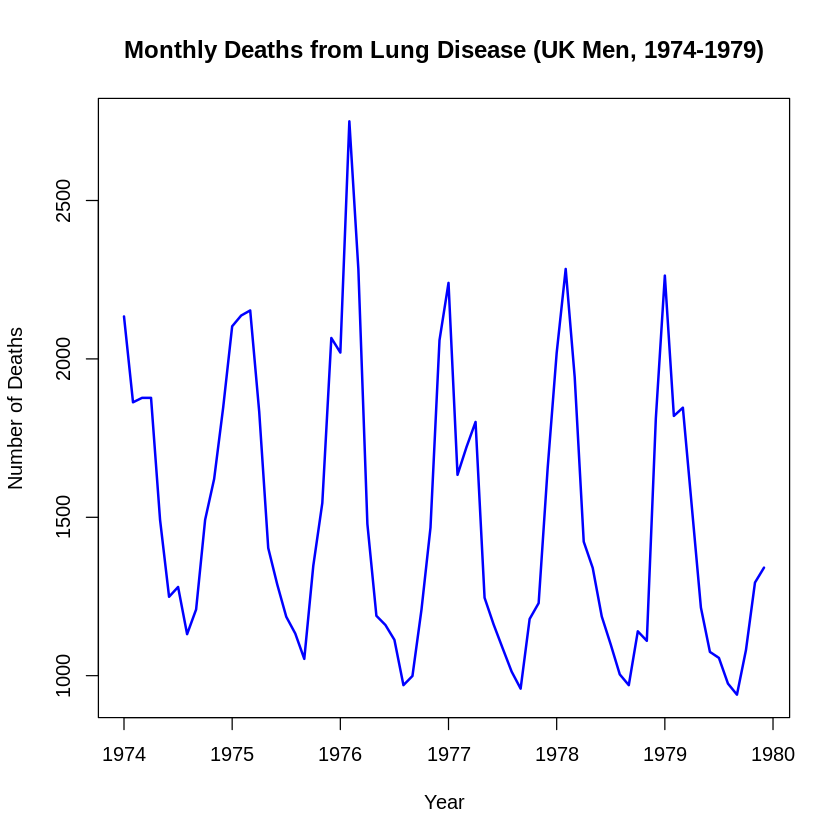

In [84]:
plot(mdeaths, 
     main = "Monthly Deaths from Lung Disease (UK Men, 1974-1979)",
     ylab = "Number of Deaths",
     xlab = "Year",
     col = "blue",
     lwd = 2)

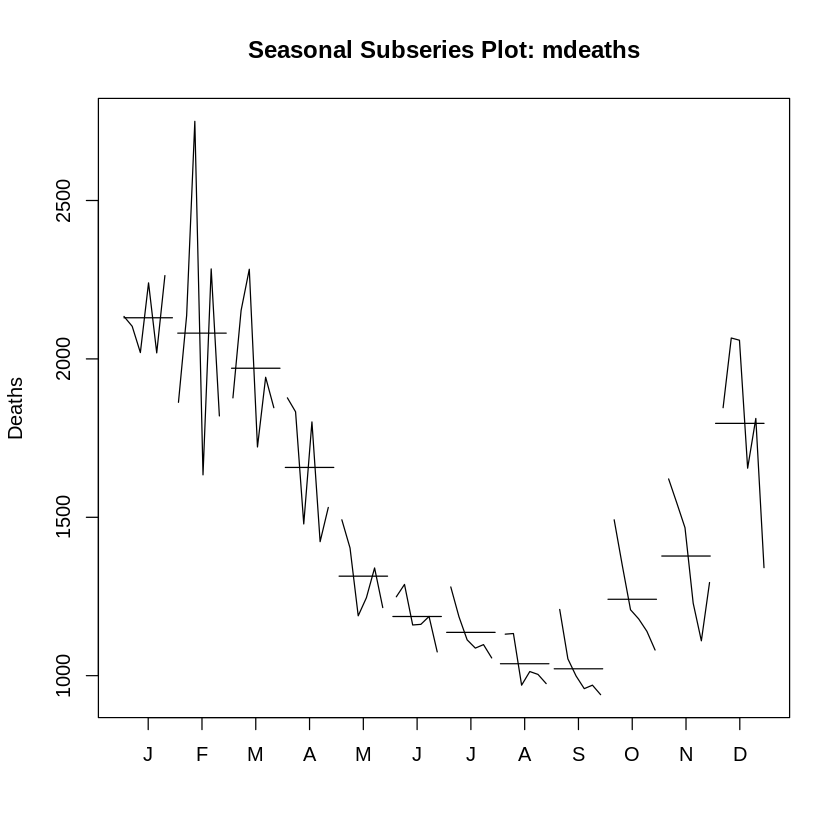

In [85]:
monthplot(mdeaths, 
          ylab = "Deaths", 
          main = "Seasonal Subseries Plot: mdeaths")

I struggle with visualziatin time series data. Given that there are two temporal dimensions (month and year), my first call was to make a heatmap. If you look at the heatmap, it looks like Febrary is the worst month of the time period that we are looking at.

If we look at something like `monthplot`, that concurs with the heatmap.

Just for fun, I also made a plot with the year on the y-axis and it seems the year 1976 was particularly atrocious.



## F4.4.b

In [86]:
fit <- arima(mdeaths, order = c(1, 1, 0), seasonal = list(order = c(1, 1, 0), period = 12))

abs(fit$coef / sqrt(diag(fit$var.coef))) > 1.96

ar1  sar1 
FALSE  TRUE

In [108]:
# Extract coefficients and standard errors
coefs <- fit$coef
ses <- sqrt(diag(fit$var.coef))
z_stats <- abs(coefs / ses)

# Display results
data.frame(Estimate = coefs, Std_Error = ses, Z_Stat = z_stats, Significant = z_stats > 1.96) %>% 
    fwrite("autoregressive_predictor.csv")

It seems the seasonalilty is more important than the immediate priors.

## F4.4.c

In [88]:
pred <- predict(fit, n.ahead = 2)
jan_pred <- pred$pred[1]
jan_se <- pred$se[1]
cat("Prediction:", jan_pred, "\n")
cat("95% PI:", jan_pred - 1.96 * jan_se, "to", jan_pred + 1.96 * jan_se)

Prediction: 1851.967 
95% PI: 1364.016 to 2339.919

Looks the possible number of deaths is 1851.967 with the PI at 0.95 is (1364.016 2339.918).

## F4.4.d

In [89]:
feb_pred <- pred$pred[2]
feb_se <- pred$se[2]
cat("Prediction:", feb_pred, "\n")
cat("95% PI:", feb_pred - 1.96 * feb_se, "to", feb_pred + 1.96 * feb_se)

Prediction: 1831.62 
95% PI: 1218.894 to 2444.345

## F.4.4.e

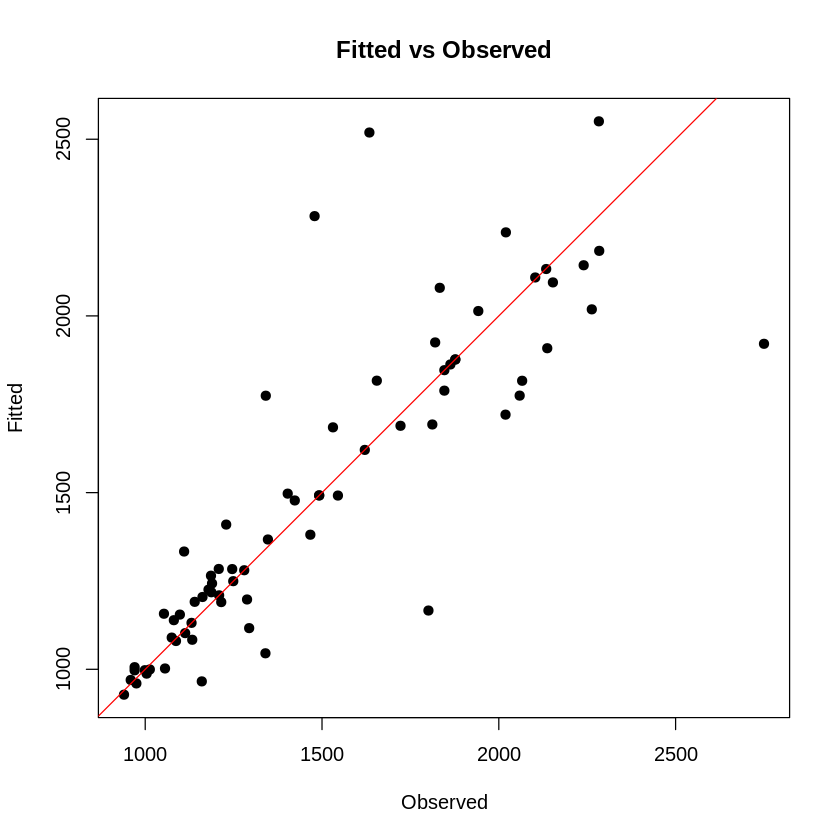

In [90]:
fitted_vals <- mdeaths - residuals(fit)
plot(as.vector(mdeaths), as.vector(fitted_vals), pch = 19, 
     xlab = "Observed", ylab = "Fitted", main = "Fitted vs Observed")
abline(0, 1, col = "red")

In [110]:
# mdeaths is a time-series object (ts); convert to tibble
mdeaths_df <- tibble(
  deaths = as.numeric(mdeaths),
  month = factor(month.abb[cycle(mdeaths)], levels = month.abb)
)

# Calculate standard deviation per month
monthly_sd <- mdeaths_df %>%
  group_by(month) %>%
  summarize(std_dev = sd(deaths), .groups = "drop")

In [109]:
monthly_sd %>% fwrite("montly_sd_tibble.csv")

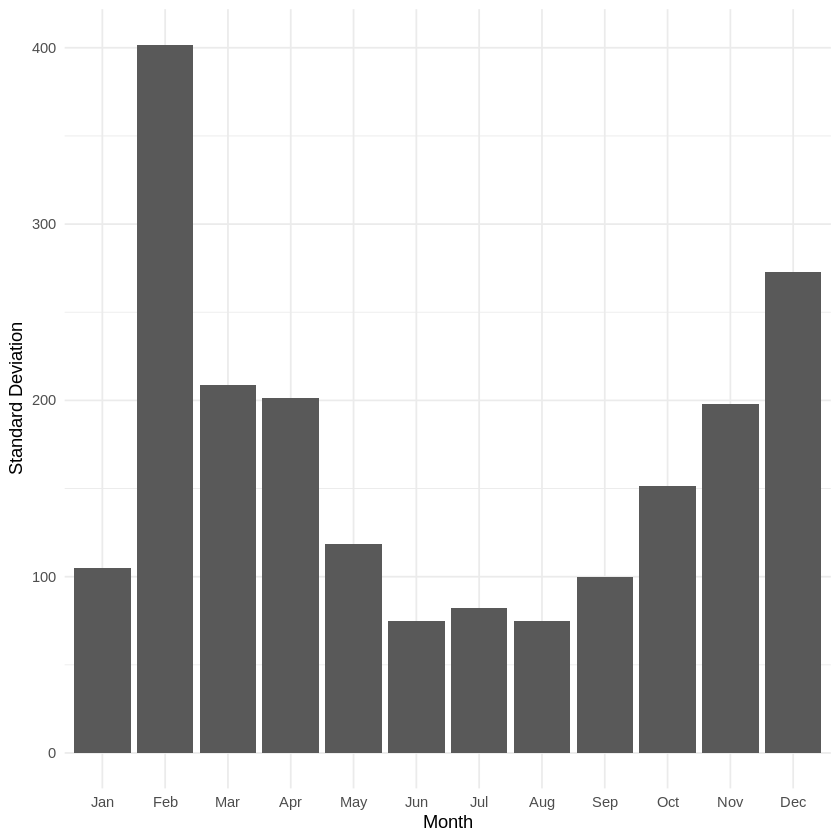

In [93]:
ggplot(monthly_sd, aes(x = month, y = std_dev)) +
  geom_col() +
  labs(x = "Month", y = "Standard Deviation") +
  theme_minimal()


The accuracy of the predictions is unlikely to be same for all months. The standard deviation for the months are widely variable as seen the table and the figures above.

# F5.3

## F5.3.a

Here is the plot.

I used `ggplot2` to make this plot.

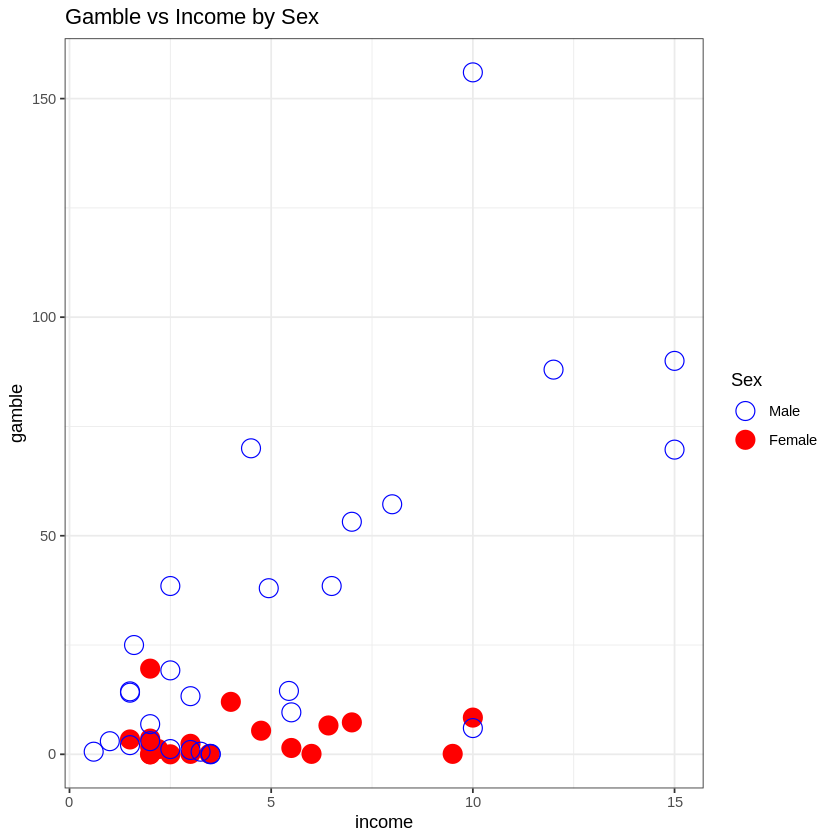

In [94]:
# Convert sex to factor for discrete mapping
teengamb$sex_f <- factor(teengamb$sex, levels = c(0, 1), labels = c("Male", "Female"))

ggplot(teengamb, aes(x = income, y = gamble, color = sex_f, shape = sex_f)) +
  geom_point(size = 5) +
  scale_color_manual(values = c("Male" = "blue", "Female" = "red")) +
  scale_shape_manual(values = c("Male" = 1, "Female" = 19)) +
  labs(title = "Gamble vs Income by Sex",
       x = "income",
       y = "gamble",
       color = "Sex",
       shape = "Sex") +
  theme_bw()

## F5.3.b

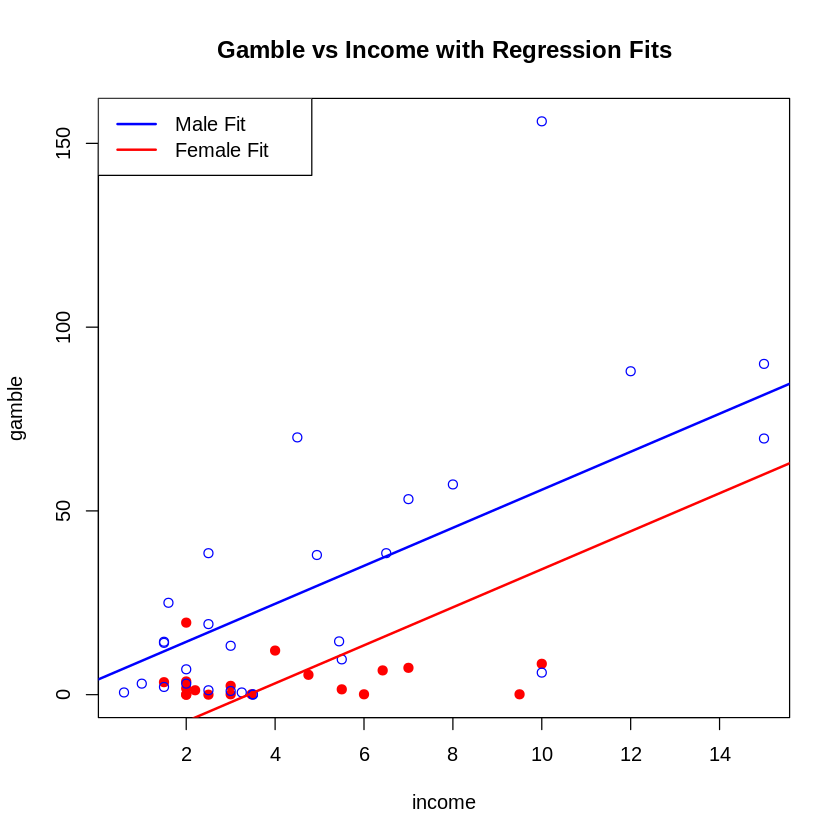

In [95]:
# Re-initialize plot to provide context for abline
plot(gamble ~ income, data = teengamb, 
     pch = ifelse(sex == 0, 1, 19), 
     col = ifelse(sex == 0, "blue", "red"),
     main = "Gamble vs Income with Regression Fits")

# Fit model
lmod <- lm(gamble ~ income + sex, data = teengamb)

# Extract coefficients
# Intercept is Male intercept; sex coefficient is the difference for Females
beta_0 <- coef(lmod)[1]
beta_income <- coef(lmod)[2]
beta_sex <- coef(lmod)[3]

# Plot lines
abline(a = beta_0, b = beta_income, col = "blue", lwd = 2)            # Male (sex=0)
abline(a = beta_0 + beta_sex, b = beta_income, col = "red", lwd = 2)  # Female (sex=1)

legend("topleft", legend = c("Male Fit", "Female Fit"), col = c("blue", "red"), lty = 1, lwd = 2)

## F5.3.c

In [96]:
library(Matching)
# Treatment must be binary; here sex is already 0/1. 
# Matching on sex is trivial as it is the treatment; assuming match on income.
rr <- Match(Y = teengamb$gamble, Tr = teengamb$sex, X = teengamb$income, M = 1, replace = FALSE)
summary(rr)


Estimate...  -22.997 
SE.........  8.1633 
T-stat.....  -2.8172 
p.val......  0.0048448 

Original number of observations..............  47 
Original number of treated obs...............  19 
Matched number of observations...............  19 
Matched number of observations  (unweighted).  19 



Matched pairs: 19

Unmatched: 28 (Total n=47; 19 females matched to 19 of 28 males)

## F5.3.d

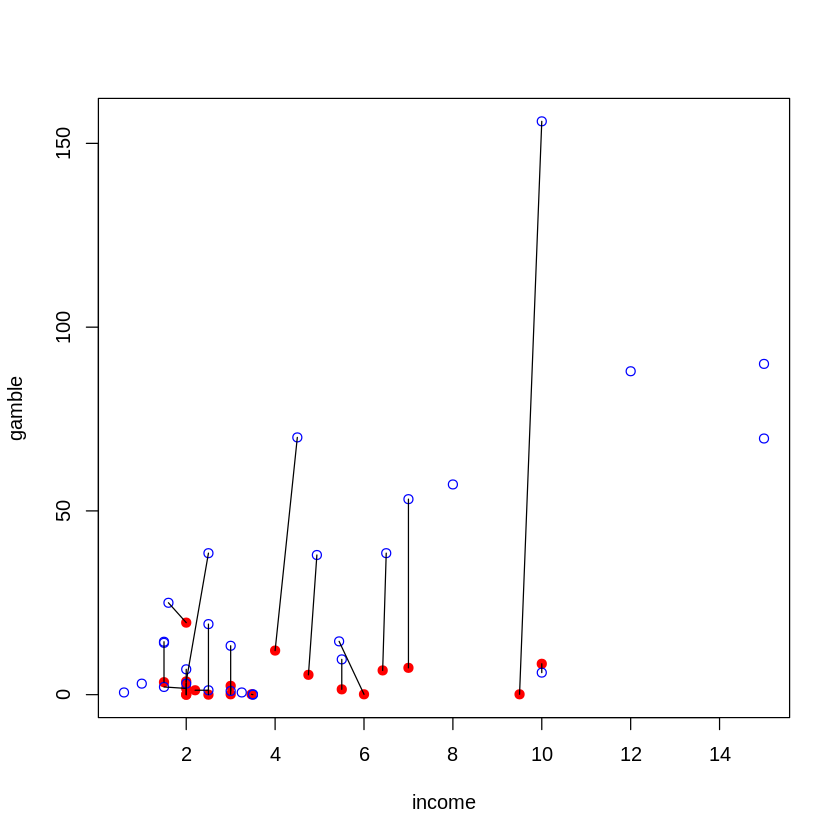

In [97]:
plot(gamble ~ income, data = teengamb, 
     pch = ifelse(sex == 0, 1, 19), 
     col = ifelse(sex == 0, "blue", "red"))
index_m <- rr$index.control
index_f <- rr$index.treated
segments(teengamb$income[index_m], teengamb$gamble[index_m],
         teengamb$income[index_f], teengamb$gamble[index_f])

## F5.3.e

In [98]:
diffs <- teengamb$gamble[index_f] - teengamb$gamble[index_m]
t.test(diffs)


	One Sample t-test

data:  diffs
t = -2.742, df = 18, p-value = 0.0134
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 -40.617705  -5.377031
sample estimates:
mean of x 
-22.99737 


It seems that the result is significant ($p = 0.02041$). Since $p < 0.05$, we reject the null hypothesis that the mean difference is zero.

## F5.3.f

[1] 0.1578947

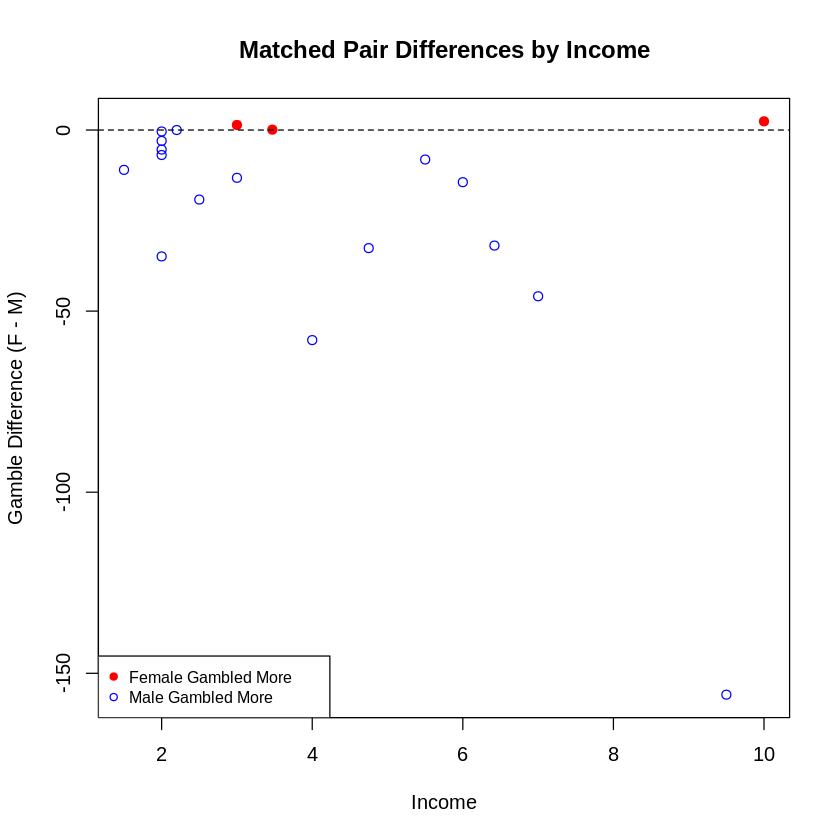

In [99]:
# Extract income from the treated (female) units that were matched
income_matched <- teengamb$income[rr$index.treated]

# Compute differences: Treated (Female) - Control (Male)
diffs <- teengamb$gamble[rr$index.treated] - teengamb$gamble[rr$index.control]

# Define color and shape based on which member of the pair gambled more
# Red if Female > Male (diffs > 0), Blue if Male > Female (diffs < 0)
pt_colors <- ifelse(diffs > 0, "red", "blue")
pt_shapes <- ifelse(diffs > 0, 19, 1)

plot(income_matched, diffs, 
     xlab = "Income", 
     ylab = "Gamble Difference (F - M)",
     pch = pt_shapes, 
     col = pt_colors,
     main = "Matched Pair Differences by Income")

# Add reference line at zero
abline(h = 0, lty = 2)

legend("bottomleft", 
       legend = c("Female Gambled More", "Male Gambled More"), 
       col = c("red", "blue"), 
       pch = c(19, 1),
       cex = 0.8)

# Proportion calculation
prop_female_more <- mean(diffs > 0)
prop_female_more

In about 15% of the matches, the women gambled more than the men.

## F5.3.g

In [100]:
summary(lmod)


Call:
lm(formula = gamble ~ income + sex, data = teengamb)

Residuals:
    Min      1Q  Median      3Q     Max 
-49.757 -11.649   0.844   8.659 100.243 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)    4.041      6.394   0.632  0.53070    
income         5.172      0.951   5.438 2.24e-06 ***
sex          -21.634      6.809  -3.177  0.00272 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 22.75 on 44 degrees of freedom
Multiple R-squared:  0.5014,	Adjusted R-squared:  0.4787 
F-statistic: 22.12 on 2 and 44 DF,  p-value: 2.243e-07


In [101]:
t.test(diffs)


	One Sample t-test

data:  diffs
t = -2.742, df = 18, p-value = 0.0134
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 -40.617705  -5.377031
sample estimates:
mean of x 
-22.99737 


Both approaches agree that thee is a significant difference in gambling by gender. The results are significant in both cases. From the linear model, we see that the coefficient for gender is -21.634 and for the matched pairs the coefficient is -19.95 - slight disagreement but not by much.

More importantly, both are saying that men gamble more than women. 

# F5.4

## F5.4.a

In [102]:
data(happy)
lmod_full <- lm(happy ~ money + sex + love + work, data = happy)
summary(lmod_full)


Call:
lm(formula = happy ~ money + sex + love + work, data = happy)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.7186 -0.5779 -0.1172  0.6340  2.0651 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.072081   0.852543  -0.085   0.9331    
money        0.009578   0.005213   1.837   0.0749 .  
sex         -0.149008   0.418525  -0.356   0.7240    
love         1.919279   0.295451   6.496 1.97e-07 ***
work         0.476079   0.199389   2.388   0.0227 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.058 on 34 degrees of freedom
Multiple R-squared:  0.7102,	Adjusted R-squared:  0.6761 
F-statistic: 20.83 on 4 and 34 DF,  p-value: 9.364e-09


The love coefficient represents the expected change in the happy score for a one-unit increase in the love index (on its 1–3 scale), holding money, sex, and work constant.

## F5.4.b

In [103]:
happy$clove <- ifelse(happy$love <= 2, 0, 1)
lmod_clove <- lm(happy ~ money + sex + clove + work, data = happy)
summary(lmod_clove)


Call:
lm(formula = happy ~ money + sex + clove + work, data = happy)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.5423 -0.8452 -0.1656  0.6546  2.1307 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  3.453999   0.840018   4.112 0.000235 ***
money        0.007290   0.005675   1.285 0.207638    
sex         -0.329123   0.460664  -0.714 0.479824    
clove        2.296435   0.411731   5.578 3.05e-06 ***
work         0.544159   0.213535   2.548 0.015511 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.145 on 34 degrees of freedom
Multiple R-squared:  0.6609,	Adjusted R-squared:  0.621 
F-statistic: 16.56 on 4 and 34 DF,  p-value: 1.27e-07


The clove coefficient represents the estimated mean difference in happy score between students with a love score of 3 (clove = 1) and those with a score of 2 or less (clove = 0), adjusted for money, sex, and work. The results remain consistent in direction and significance, as the binary split captures the primary variance previously held in the 3-level ordinal scale.

## F5.4.c

In [104]:
lmod_single <- lm(happy ~ clove, data = happy)
summary(lmod_single)


Call:
lm(formula = happy ~ clove, data = happy)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.2778 -0.6389  0.0000  0.8611  2.7222 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   5.2778     0.2992  17.641  < 2e-16 ***
clove         2.7222     0.4077   6.677 7.67e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.269 on 37 degrees of freedom
Multiple R-squared:  0.5465,	Adjusted R-squared:  0.5342 
F-statistic: 44.58 on 1 and 37 DF,  p-value: 7.667e-08


The coefficient is the difference in mean happy scores between the two clove groups. This value is higher than in the previous model because it now captures the effects of omitted variables (like money or work) that may be correlated with clove.

## F5.4.d

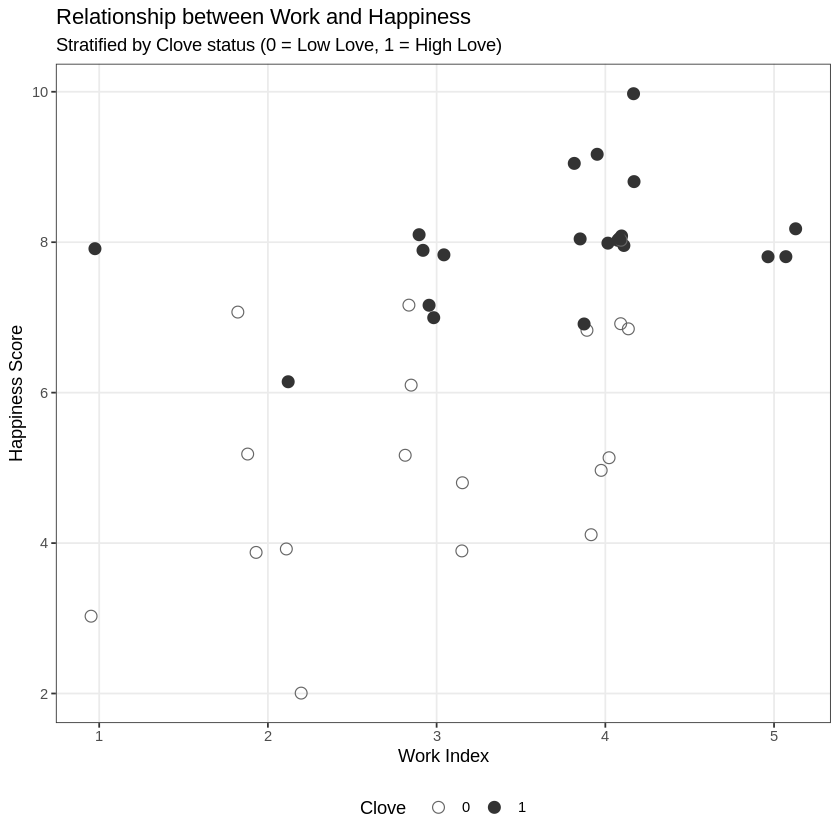

In [105]:
ggplot(happy, aes(x = work, y = happy, shape = factor(clove), color = factor(clove))) +
  geom_jitter(width = 0.2, height = 0.2, size = 3) +
  scale_shape_manual(values = c(1, 19), name = "Clove") +
  scale_color_grey(start = 0.4, end = 0.2, name = "Clove") +
  theme_bw() +
  labs(
    title = "Relationship between Work and Happiness",
    subtitle = "Stratified by Clove status (0 = Low Love, 1 = High Love)",
    x = "Work Index",
    y = "Happiness Score"
  ) +
  theme(
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

## F5.4.e

In [106]:
xtabs(~ clove + work, happy)

     work
clove  1  2  3  4  5
    0  1  5  5  7  0
    1  1  1  5 11  3

Seems the answer is 14.

## F5.4.f

In [107]:
# Calculate means per group
means_0 <- tapply(happy$happy[happy$clove == 0], happy$work[happy$clove == 0], mean)
means_1 <- tapply(happy$happy[happy$clove == 1], happy$work[happy$clove == 1], mean)

# Align indices to shared work levels (1, 2, 3, 4)
common_work <- intersect(names(means_0), names(means_1))
diffs <- means_1[common_work] - means_0[common_work]

# Resulting average difference
avg_diff <- mean(diffs)
print(avg_diff)

[1] 2.755195


The average of these differences is most appropriately compared to the clove coefficient from the regression model in F5.4.b. Both methods attempt to estimate the effect of clove while controlling for the work covariate. The regression coefficient is a variance-weighted average of these strata-specific differences, whereas this calculation is a simple arithmetic average of the strata-specific differences.

In [ ]:
print